# 1. Importar librerias

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

# 2. Abrir csv y cribado manual

In [35]:
df = pd.read_csv("/workspaces/steven10015-intro-ml/data/raw/winequality-red.csv", sep =';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [36]:
df.shape

(1599, 12)

## 2.1 Valores unicos

In [37]:
unicos = df.nunique()
df[unicos[unicos == 1].index]

""
0
1
2
3
4
...
1594
1595
1596
1597


## 2.2 Valores duplicados en filas

In [38]:
filas_dupli = df.duplicated()
df[filas_dupli]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [39]:
df.drop_duplicates(inplace=True)
df.shape

(1359, 12)

## 2.3 Columnas con valores iguales

In [40]:
dup_col=df.T.duplicated(keep=False).sum()
print("No hay variables exactamente iguales" if dup_col==0 else "Hay variables exactamente iguales")

No hay variables exactamente iguales


## 2.4 Valores faltantes

In [41]:
missing=df.isna().mean()*100
missing[missing>15]

Series([], dtype: float64)

In [42]:
fila_datos_faltantes = df.isna().any(axis=1).sum() # any sirve para ver CUALQUIER dato faltante
fila_datos_faltantes[fila_datos_faltantes>0] # primer tipo de código para ver estas condiciones
n = 2 # segundo tipo de código, se probaron varios números, 2 fue el primero con na
df[df.isna().sum(axis=1) > n] # se los visualiza, su sintaxis es seleccionar valores/dividirlos por col.fila/condición para mostrarlos.

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


# 3. Split train/test

In [43]:
# Crear la etiqueta (target) según la calidad
# 0: Baja (<=4), 1: Media (5-6), 2: Alta (>=7)
def categorizar(q):
    if q <= 4: return 0
    elif q <= 6: return 1
    else: return 2

df['label'] = df['quality'].apply(categorizar)

# Separar variables independientes (X) de la dependiente (y)
# Quitamos 'quality' (porque es la original) y 'label' (que es el objetivo)
X = df.drop(['quality', 'label'], axis=1)
y = df['label']

# División en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Datos divididos correctamente.")

Datos divididos correctamente.


# 4. Escalar datos

In [44]:
scaler = StandardScaler()

# Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los de prueba con el mismo ajuste
X_test_scaled = scaler.transform(X_test)

print("Datos escalados.")

Datos escalados.


# 5. Entrenamiento y evaluación

In [45]:
# Entrenar modelo inicial
k_inicial = 5
knn = KNeighborsClassifier(n_neighbors=k_inicial)
knn.fit(X_train_scaled, y_train)

# Predicción
y_pred = knn.predict(X_test_scaled)

# Mostrar métricas
print(f"--- RESULTADOS CON K={k_inicial} ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

--- RESULTADOS CON K=5 ---
Accuracy Score: 0.8199

Matriz de Confusión:
[[  0  15   0]
 [  3 207  13]
 [  0  18  16]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.86      0.93      0.89       223
           2       0.55      0.47      0.51        34

    accuracy                           0.82       272
   macro avg       0.47      0.47      0.47       272
weighted avg       0.78      0.82      0.80       272



## 6. Optimización de K y gráfica

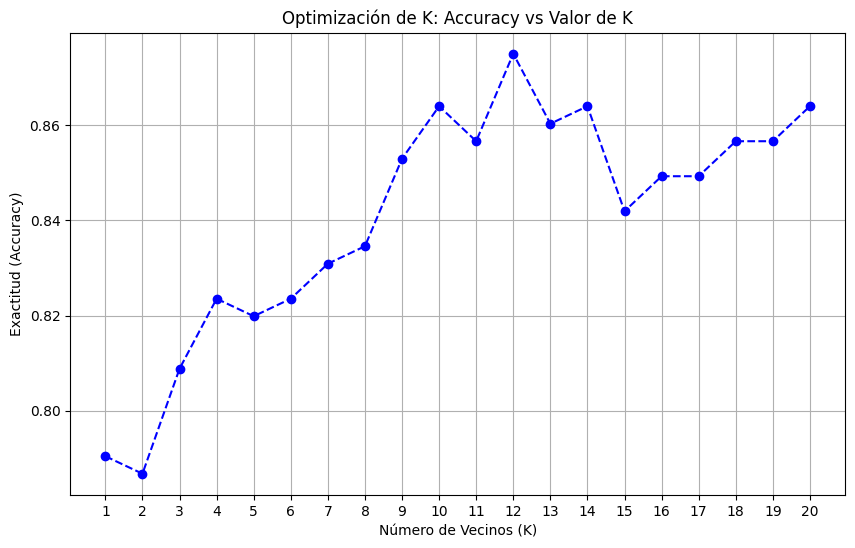

El mejor valor de K es 12 con una exactitud de 0.8750


In [46]:
# Bucle para probar diferentes valores de k
k_values = range(1, 21)
accuracy_resultados = []

for k in k_values:
    modelo_temp = KNeighborsClassifier(n_neighbors=k)
    modelo_temp.fit(X_train_scaled, y_train)
    pred_temp = modelo_temp.predict(X_test_scaled)
    accuracy_resultados.append(accuracy_score(y_test, pred_temp))

# Graficar Accuracy vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_resultados, marker='o', linestyle='--', color='blue')
plt.title('Optimización de K: Accuracy vs Valor de K')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Exactitud (Accuracy)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Encontrar el mejor K
mejor_k = k_values[np.argmax(accuracy_resultados)]
print(f"El mejor valor de K es {mejor_k} con una exactitud de {max(accuracy_resultados):.4f}")

El valor de K=12 permitió al modelo encontrar el equilibrio justo entre ser muy sensible al ruido y ser demasiado generalista.  
El modelo es muy bueno detectando vinos de calidad media, pero le cuesta más identificar los extremos debido a que hay menos datos de esos vinos.
